In [1]:

import re
import ssl
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer, word_tokenize

try:
    _create_unverified_https_context = ssl._create_unverified_context
    ssl._create_default_https_context = _create_unverified_https_context
except AttributeError:
    pass
#ako su potrebne instalacije 
#nltk.download("stopwords")
#nltk.download("wordnet")


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import TruncatedSVD


from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)


import joblib

In [2]:
data=pd.read_csv('../../Reviews.csv')
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
data["Score"].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

In [4]:
data_small, _ = train_test_split(
    data,
    train_size=50000,
    stratify=data["Score"],
    random_state=42
)
data_small["Score"].value_counts()

Score
5    31940
4     7094
1     4597
3     3751
2     2618
Name: count, dtype: int64

In [5]:
data_small.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               2
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   3
Text                      0
dtype: int64

In [6]:
data_small["TextFull"] = data_small["Summary"].fillna("") + " " + data_small["Text"].fillna("")


In [7]:
data_small.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,TextFull
377432,377433,B001AML2LI,AK3SUUL1WSM7G,"carobonly ""rosered""",3,5,4,1190592000,good for 100 calories,"Not bad for being only 100 calories, crispy an...",good for 100 calories Not bad for being only 1...
357755,357756,B001GCTTRQ,A333ABL4WW067D,Brandy,0,0,1,1332374400,Fish tea,"I know nettle tea has a pretty distinct taste,...",Fish tea I know nettle tea has a pretty distin...
483229,483230,B00282QG6U,A2H7FG21UZLYR4,Amazon Prime Member,0,0,5,1350345600,Great Stuff here,I have ordered all kinds of SweetLeaf Stevia p...,Great Stuff here I have ordered all kinds of S...
98424,98425,B004GW6O9E,A3VFNQBW7VY938,Isabelle Rowe,0,0,5,1336694400,Wonderful taste. Love these bars,This was the first time I purchased this flavo...,Wonderful taste. Love these bars This was the ...
106314,106315,B001QZZ1J8,A2DWNAHNLA7NK7,V. Kneifl,5,5,5,1264204800,Best cornbread I've ever tasted!,"For years, I've been looking for cornbread lik...","Best cornbread I've ever tasted! For years, I'..."


In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

data_small["cleaned_full"] = data_small["TextFull"].apply(clean_text)

In [9]:
final_data = data_small[["cleaned_full","Score"]]

In [10]:
final_data.head()


,cleaned_full,Score
377432,good calorie bad calorie crispy crunchy defini...,4
357755,fish tea know nettle tea pretty distinct taste...,1
483229,great stuff ordered kind sweetleaf stevia prod...,5
98424,wonderful taste love bar first time purchased ...,5
106314,best cornbread ever tasted year looking cornbr...,5


In [11]:
X = final_data["cleaned_full"]
y = final_data["Score"]

X_full_train, X_full_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
models = {
    "LinearSVC": LinearSVC(dual="auto", max_iter=5000),
    "SGD hinge": SGDClassifier(loss="hinge", random_state=42),
    "LogReg": LogisticRegression(max_iter=500, n_jobs=-1),
    "Random forest": RandomForestClassifier(n_estimators=300,max_depth=30,random_state=42),
    "ComplementNB": ComplementNB(),
}

tfidf_settings = {
    "TFIDF_10k": dict(max_features=10000, ngram_range=(1,2), min_df=2),
    "TFIDF_20k": dict(max_features=20000, ngram_range=(1,2), min_df=2),
}

def run_block(Xtr, Xte, ytr, yte, label):
    rows = []
    for tfidf_name, tfidf_kwargs in tfidf_settings.items():
        for model_name, model in models.items():

            

            print(f"Treniram: {label} | {tfidf_name} | {model_name} ...")

            pipe = Pipeline([
                ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
                ("clf", clone(model))
            ])

            pipe.fit(Xtr, ytr)
            pred = pipe.predict(Xte)

            acc = accuracy_score(yte, pred)
            f1m = f1_score(yte, pred, average="macro")
            f1w = f1_score(yte, pred, average="weighted")

            print(f"  -> done | acc={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f}")

            rows.append({
                "Dataset": label,          
                "TFIDF": tfidf_name,
                "Model": model_name,
                "Accuracy": acc,
                "F1_macro": f1m,
                "F1_weighted": f1w,
            })
    return rows

In [13]:
train_df = pd.DataFrame({
    "cleaned_full": X_full_train,
    "Score": y_train
})

min_count = train_df["Score"].value_counts().min()

train_bal = (
    train_df.groupby("Score", group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .sample(frac=1, random_state=42)
)

X_full_train_bal = train_bal["cleaned_full"]
y_train_bal = train_bal["Score"]

In [14]:
rows = []
rows += run_block(X_full_train,     X_full_test, y_train,     y_test, "RAW")
rows += run_block(X_full_train_bal, X_full_test, y_train_bal, y_test, "BAL")

results_df = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df

Treniram: RAW | TFIDF_10k | LinearSVC ...
  -> done | acc=0.7313 | f1_macro=0.5127 | f1_weighted=0.7064
Treniram: RAW | TFIDF_10k | SGD hinge ...
  -> done | acc=0.7161 | f1_macro=0.4068 | f1_weighted=0.6443
Treniram: RAW | TFIDF_10k | LogReg ...
  -> done | acc=0.7352 | f1_macro=0.4845 | f1_weighted=0.6946
Treniram: RAW | TFIDF_10k | Random forest ...
  -> done | acc=0.6513 | f1_macro=0.2081 | f1_weighted=0.5252
Treniram: RAW | TFIDF_10k | ComplementNB ...
  -> done | acc=0.6889 | f1_macro=0.4583 | f1_weighted=0.6808
Treniram: RAW | TFIDF_20k | LinearSVC ...
  -> done | acc=0.7348 | f1_macro=0.5190 | f1_weighted=0.7117
Treniram: RAW | TFIDF_20k | SGD hinge ...
  -> done | acc=0.7151 | f1_macro=0.4033 | f1_weighted=0.6421
Treniram: RAW | TFIDF_20k | LogReg ...
  -> done | acc=0.7347 | f1_macro=0.4824 | f1_weighted=0.6923
Treniram: RAW | TFIDF_20k | Random forest ...
  -> done | acc=0.6447 | f1_macro=0.1819 | f1_weighted=0.5112
Treniram: RAW | TFIDF_20k | ComplementNB ...
  -> done | ac

,Dataset,TFIDF,Model,Accuracy,F1_macro,F1_weighted
5,RAW,TFIDF_20k,LinearSVC,0.7348,0.518952,0.711749
0,RAW,TFIDF_10k,LinearSVC,0.7313,0.512691,0.706353
18,BAL,TFIDF_20k,Random forest,0.6453,0.486364,0.662518
2,RAW,TFIDF_10k,LogReg,0.7352,0.484471,0.694642
7,RAW,TFIDF_20k,LogReg,0.7347,0.482395,0.692340
16,BAL,TFIDF_20k,SGD hinge,0.6266,0.477333,0.650062
17,BAL,TFIDF_20k,LogReg,0.6052,0.476105,0.637559
11,BAL,TFIDF_10k,SGD hinge,0.6290,0.474899,0.651525
9,RAW,TFIDF_20k,ComplementNB,0.7076,0.474633,0.693382
13,BAL,TFIDF_10k,Random forest,0.6344,0.473667,0.652884


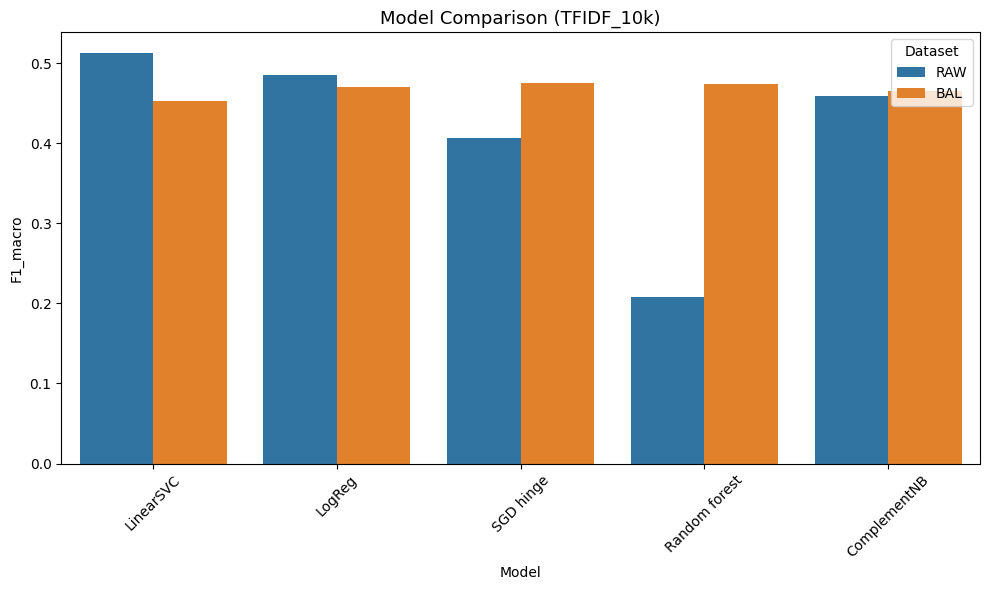

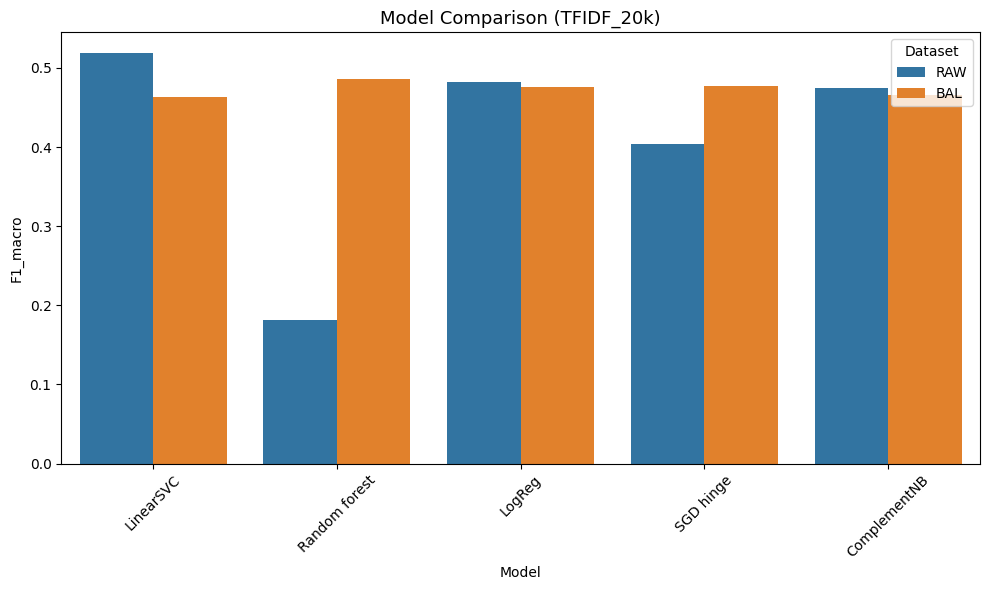

In [15]:
for tfidf_name in ["TFIDF_10k", "TFIDF_20k"]:
    plt.figure(figsize=(10,6))
    
    sub = results_df[results_df["TFIDF"] == tfidf_name]
    
    sns.barplot(
        data=sub,
        x="Model",
        y="F1_macro",
        hue="Dataset",
    )
    
    plt.xticks(rotation=45)
    plt.title(f"Model Comparison ({tfidf_name})", fontsize=13)
    plt.tight_layout()
    plt.show()

In [18]:
def show_cm_raw_vs_bal_for_model(
    model_name,
    tfidf_name,
    X_train, y_train,
    X_train_bal, y_train_bal,
    X_test, y_test,
    title_prefix="SCORE",
    normalize="true"
):
    print("="*90)
    print(f"{title_prefix} | Model: {model_name} | {tfidf_name}")
    print("="*90)

    tfidf_kwargs = tfidf_settings[tfidf_name]

    pipe_raw = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
        ("clf",clone( models[model_name]))
    ])
    pipe_raw.fit(X_train, y_train)

    pred_raw_tr = pipe_raw.predict(X_train)
    pred_raw_te = pipe_raw.predict(X_test)

    cm_raw_tr = confusion_matrix(y_train, pred_raw_tr, normalize=normalize)
    cm_raw_te = confusion_matrix(y_test, pred_raw_te, normalize=normalize)

    pipe_bal = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
        ("clf", clone(models[model_name]))
    ])
    pipe_bal.fit(X_train_bal, y_train_bal)

    pred_bal_tr = pipe_bal.predict(X_train_bal)
    pred_bal_te = pipe_bal.predict(X_test)

    cm_bal_tr = confusion_matrix(y_train_bal, pred_bal_tr, normalize=normalize)
    cm_bal_te = confusion_matrix(y_test, pred_bal_te, normalize=normalize)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ConfusionMatrixDisplay(cm_raw_tr).plot(ax=axes[0,0], cmap="Blues", colorbar=False)
    axes[0,0].set_title("RAW | TRAIN")
    axes[0,0].grid(False)

    ConfusionMatrixDisplay(cm_raw_te).plot(ax=axes[0,1], cmap="Blues", colorbar=False)
    axes[0,1].set_title("RAW | TEST")
    axes[0,1].grid(False)

    ConfusionMatrixDisplay(cm_bal_tr).plot(ax=axes[1,0], cmap="Blues", colorbar=False)
    axes[1,0].set_title("BAL | TRAIN")
    axes[1,0].grid(False)

    ConfusionMatrixDisplay(cm_bal_te).plot(ax=axes[1,1], cmap="Blues", colorbar=False)
    axes[1,1].set_title("BAL | TEST")
    axes[1,1].grid(False)

    plt.suptitle(f"{title_prefix}: {model_name} | {tfidf_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n--- RAW | TRAIN report ---")
    print(classification_report(y_train, pred_raw_tr))

    print("\n--- RAW | TEST report ---")
    print(classification_report(y_test, pred_raw_te))

    print("\n--- BAL | TRAIN report ---")
    print(classification_report(y_train_bal, pred_bal_tr))

    print("\n--- BAL | TEST report ---")
    print(classification_report(y_test, pred_bal_te))

SCORE | Model: LinearSVC | TFIDF_20k


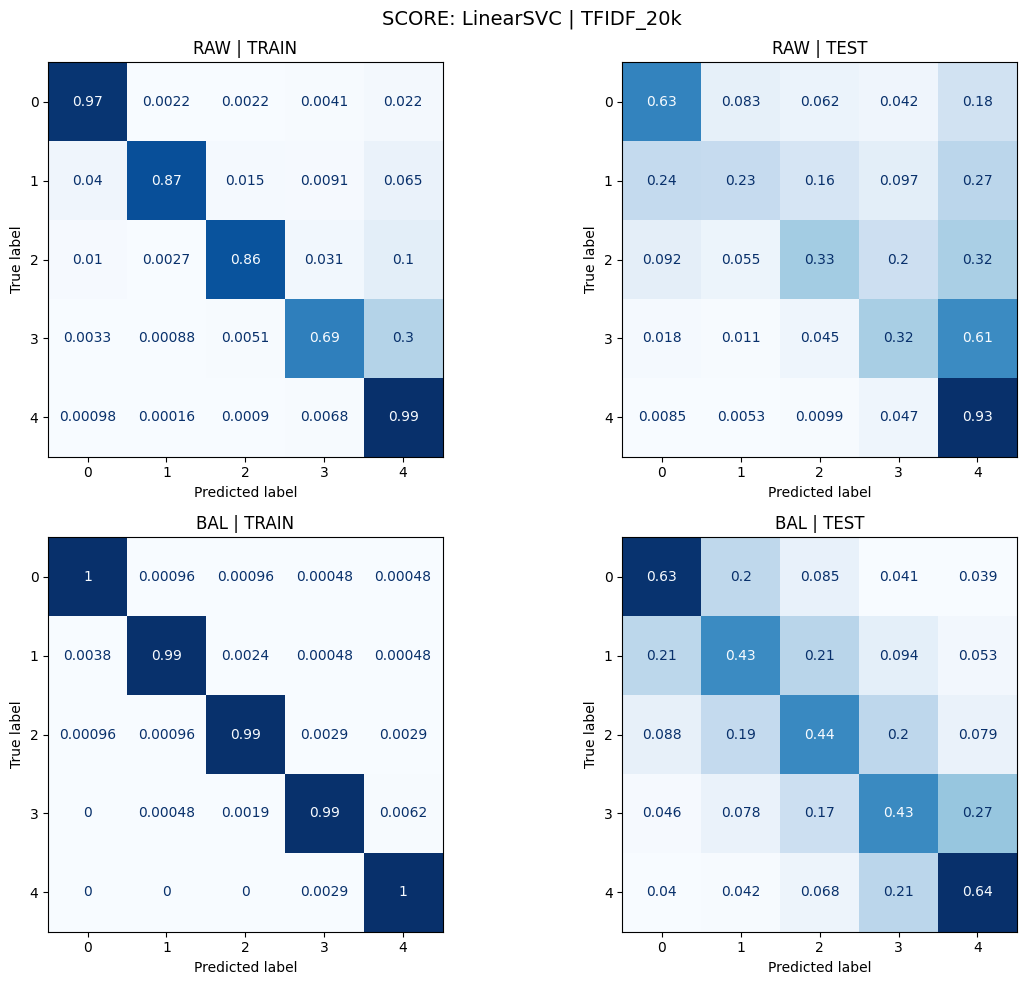


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.96      0.97      0.96      3678
           2       0.99      0.87      0.93      2094
           3       0.97      0.86      0.91      3001
           4       0.93      0.69      0.79      5675
           5       0.92      0.99      0.95     25552

    accuracy                           0.93     40000
   macro avg       0.95      0.88      0.91     40000
weighted avg       0.93      0.93      0.93     40000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.68      0.63      0.65       919
           2       0.43      0.23      0.30       524
           3       0.48      0.33      0.40       750
           4       0.46      0.32      0.38      1419
           5       0.81      0.93      0.87      6388

    accuracy                           0.73     10000
   macro avg       0.57      0.49      0.52     10000
weighted avg       0.7

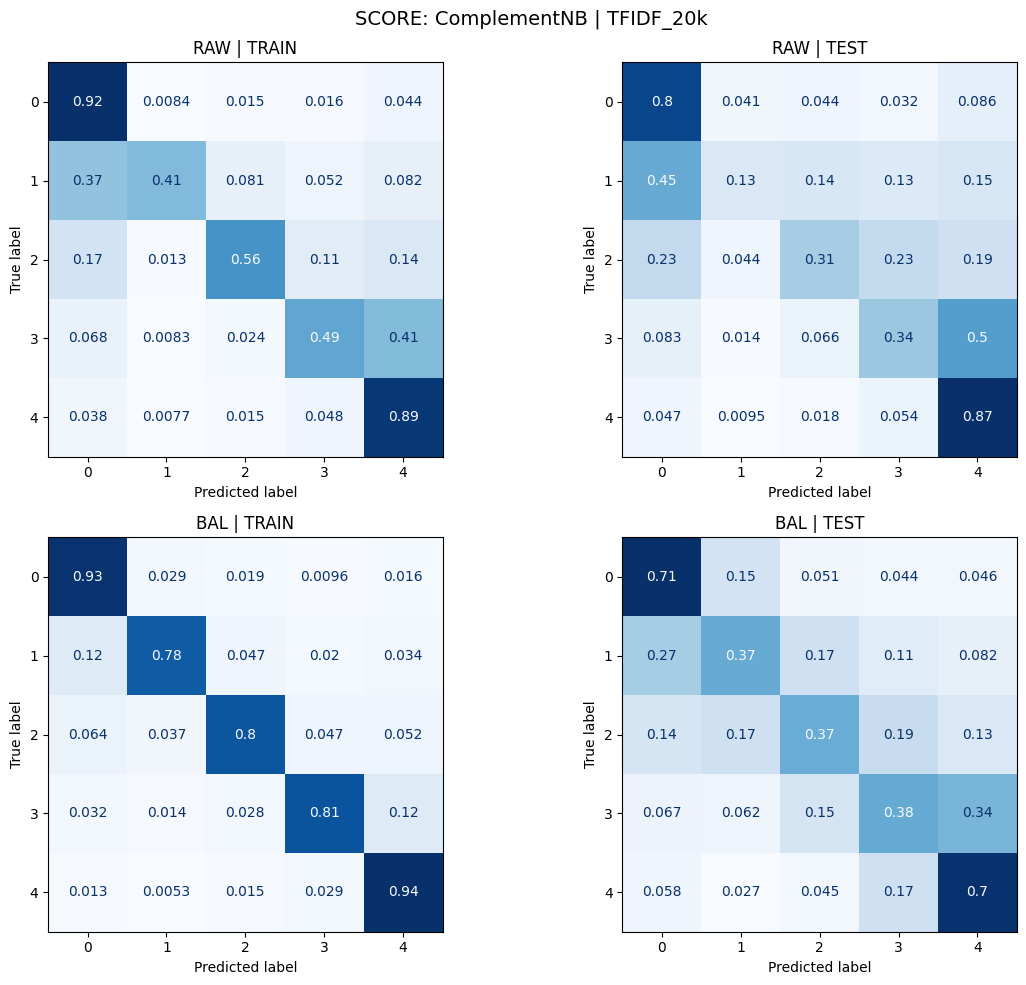


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.56      0.92      0.69      3678
           2       0.73      0.41      0.53      2094
           3       0.69      0.56      0.62      3001
           4       0.62      0.49      0.55      5675
           5       0.88      0.89      0.89     25552

    accuracy                           0.79     40000
   macro avg       0.70      0.65      0.66     40000
weighted avg       0.79      0.79      0.78     40000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.47      0.80      0.59       919
           2       0.32      0.13      0.19       524
           3       0.42      0.31      0.35       750
           4       0.44      0.34      0.38      1419
           5       0.85      0.87      0.86      6388

    accuracy                           0.71     10000
   macro avg       0.50      0.49      0.47     10000
weighted avg       0.6

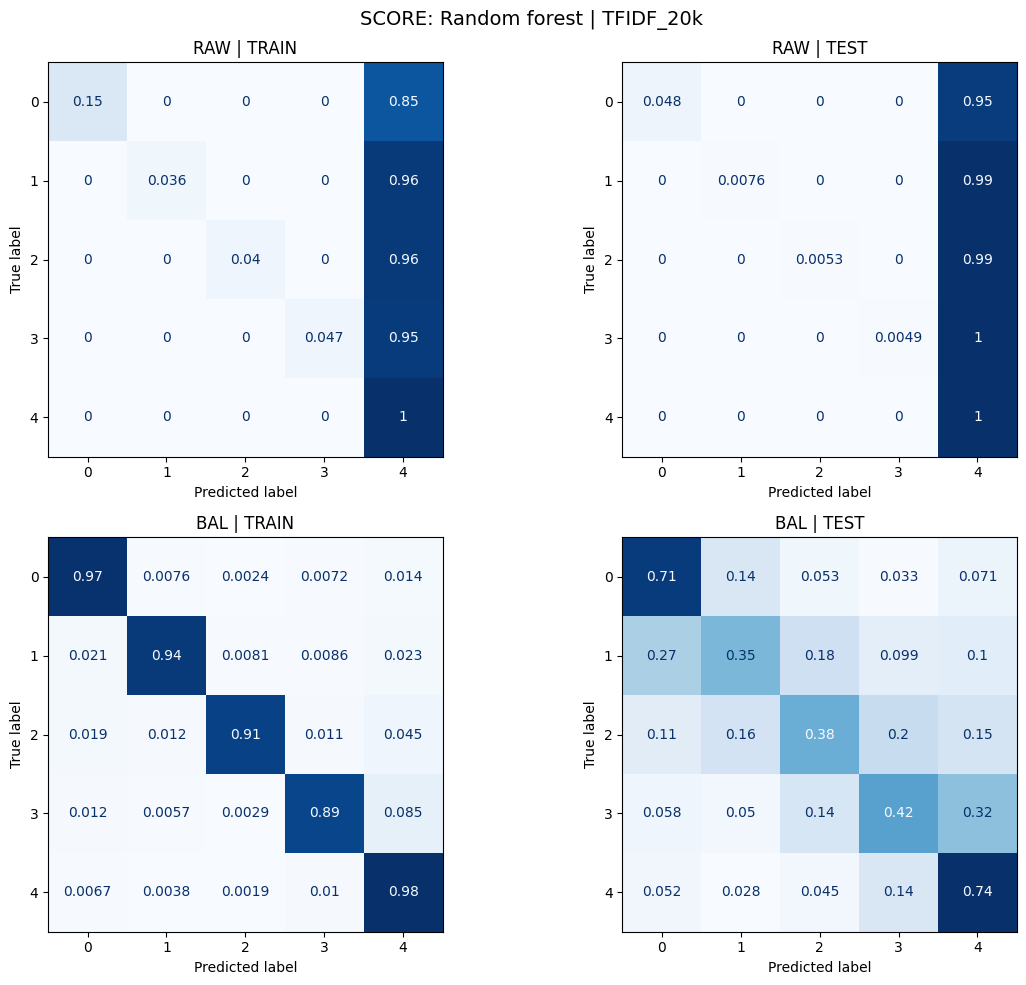


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       1.00      0.15      0.26      3678
           2       1.00      0.04      0.07      2094
           3       1.00      0.04      0.08      3001
           4       1.00      0.05      0.09      5675
           5       0.66      1.00      0.79     25552

    accuracy                           0.66     40000
   macro avg       0.93      0.25      0.26     40000
weighted avg       0.78      0.66      0.55     40000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       1.00      0.05      0.09       919
           2       1.00      0.01      0.02       524
           3       1.00      0.01      0.01       750
           4       1.00      0.00      0.01      1419
           5       0.64      1.00      0.78      6388

    accuracy                           0.64     10000
   macro avg       0.93      0.21      0.18     10000
weighted avg       0.7

In [ ]:
chosen_models = ["LinearSVC", "ComplementNB", "Random forest","LogReg","SGD hinge"]

for m in chosen_models:
    show_cm_raw_vs_bal_for_model(
        model_name=m,
        tfidf_name="TFIDF_20k",   # ili "TFIDF_10k"
        X_train=X_full_train, y_train=y_train,
        X_train_bal=X_full_train_bal, y_train_bal=y_train_bal,
        X_test=X_full_test, y_test=y_test,
        title_prefix="SCORE"
    )

In [ ]:
NB_MODELS = ( ComplementNB)

def run_tfidf20k_svd_only(Xtr, Xte, ytr, yte, k=300, label="RAW"):
    rows = []
    tfidf_kwargs = tfidf_settings["TFIDF_10k"]

    print("="*60)
    print(f"EKSPERIMENT | Dataset: {label} | TFIDF_10k + SVD({k})")
    print("="*60)

    for model_name, model in models.items():

        # NB preskacemo jer SVD moze dati negativne vrednosti
        if isinstance(model, NB_MODELS):
            print(f"Preskacem {model_name} + SVD (negativne vrednosti)")
            continue

        rep = f"TFIDF_10k+SVD({k})"
        steps = [
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("svd", TruncatedSVD(n_components=k, random_state=42)),
            ("clf",clone( model)),
        ]
        pipe = Pipeline(steps)

        print(f"\nTreniram: {model_name} | {rep}")
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)

        acc = accuracy_score(yte, pred)
        f1m = f1_score(yte, pred, average="macro")
        f1w = f1_score(yte, pred, average="weighted")

        evr_sum = float(pipe.named_steps["svd"].explained_variance_ratio_.sum())
        print(f"    SVD explained variance sum = {evr_sum:.4f}")
        print(f"    Done | Acc={acc:.4f} | F1_macro={f1m:.4f} | F1_weighted={f1w:.4f}")

        rows.append({
            "Dataset": label,
            "Rep": rep,
            "Model": model_name,
            "Accuracy": acc,
            "F1_macro": f1m,
            "F1_weighted": f1w,
            "SVD_explained_var_sum": evr_sum
        })

    print("\nEksperiment zavrsen.\n")
    return pd.DataFrame(rows).sort_values("F1_macro", ascending=False)

In [ ]:
df_example = run_tfidf20k_svd_only(
    X_full_train,
    X_full_test,
    y_train,
    y_test,
    k=300,
    label="RAW"
)

df_example

In [ ]:
def show_cm_tfidf_svd(
    model_name,
    X_train, y_train,
    X_test, y_test,
    k=300,
    tfidf_name="TFIDF_10k",
    title_prefix="SCORE",
    normalize="true"
):
    if isinstance(models[model_name], NB_MODELS):
        print(f"Preskacem {model_name} + SVD (negativne vrednosti)")
        return

    tfidf_kwargs = tfidf_settings[tfidf_name]

    print("="*80)
    print(f"{title_prefix} | {model_name} | {tfidf_name} + SVD({k})")
    print("="*80)

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
        ("svd", TruncatedSVD(n_components=k, random_state=42)),
        ("clf", clone(models[model_name]))
    ])

    pipe.fit(X_train, y_train)

    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)

    cm_tr = confusion_matrix(y_train, pred_tr, normalize=normalize)
    cm_te = confusion_matrix(y_test, pred_te, normalize=normalize)

    # ===== PLOT =====
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    ConfusionMatrixDisplay(cm_tr).plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title("TRAIN")
    axes[0].grid(False)

    ConfusionMatrixDisplay(cm_te).plot(ax=axes[1], cmap="Blues", colorbar=False)
    axes[1].set_title("TEST")
    axes[1].grid(False)

    plt.suptitle(f"{model_name} | {tfidf_name} + SVD({k})", fontsize=13)
    plt.tight_layout()
    plt.show()

    print("\n--- TRAIN report ---")
    print(classification_report(y_train, pred_tr))

    print("\n--- TEST report ---")
    print(classification_report(y_test, pred_te))

In [ ]:

best_model = df_example.iloc[0]["Model"]
print("Najbolji SVD model:", best_model)

show_cm_tfidf_svd(
    model_name=best_model,
    X_train=X_full_train,
    y_train=y_train,
    X_test=X_full_test,
    y_test=y_test,
    k=300
)

In [ ]:

def plot_svd_variance(Xtr, tfidf_kwargs, ks=(100,300,500)):
    tfidf = TfidfVectorizer(**tfidf_kwargs)
    X = tfidf.fit_transform(Xtr)

    sums = []
    for k in ks:
        svd = TruncatedSVD(n_components=k, random_state=42)
        svd.fit(X)
        sums.append(svd.explained_variance_ratio_.sum())
        print(f"  -> done | k={k:.4f}")

    plt.figure()
    plt.plot(list(ks), sums, marker="o")
    plt.title("TruncatedSVD: kumulativna objašnjena varijansa")
    plt.xlabel("Broj komponenti (k)")
    plt.ylabel("Σ explained_variance_ratio_")
    plt.grid(True)
    plt.show()

plot_svd_variance(X_full_train, tfidf_settings["TFIDF_10k"], ks=(100,300,500))
